Saved d_band_properties_extended.csv


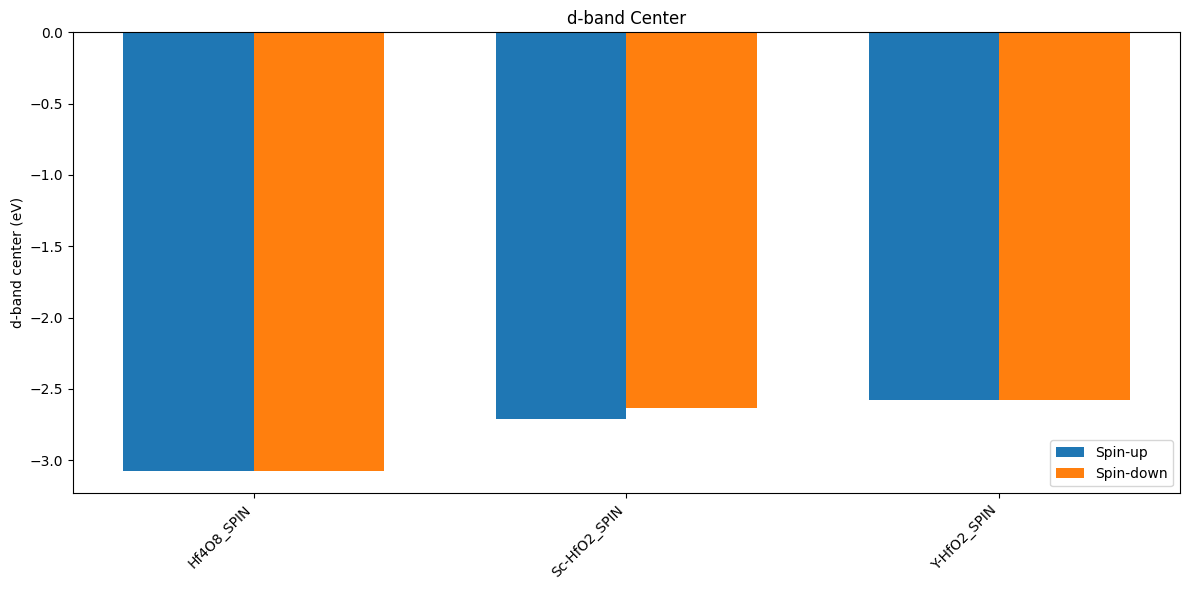

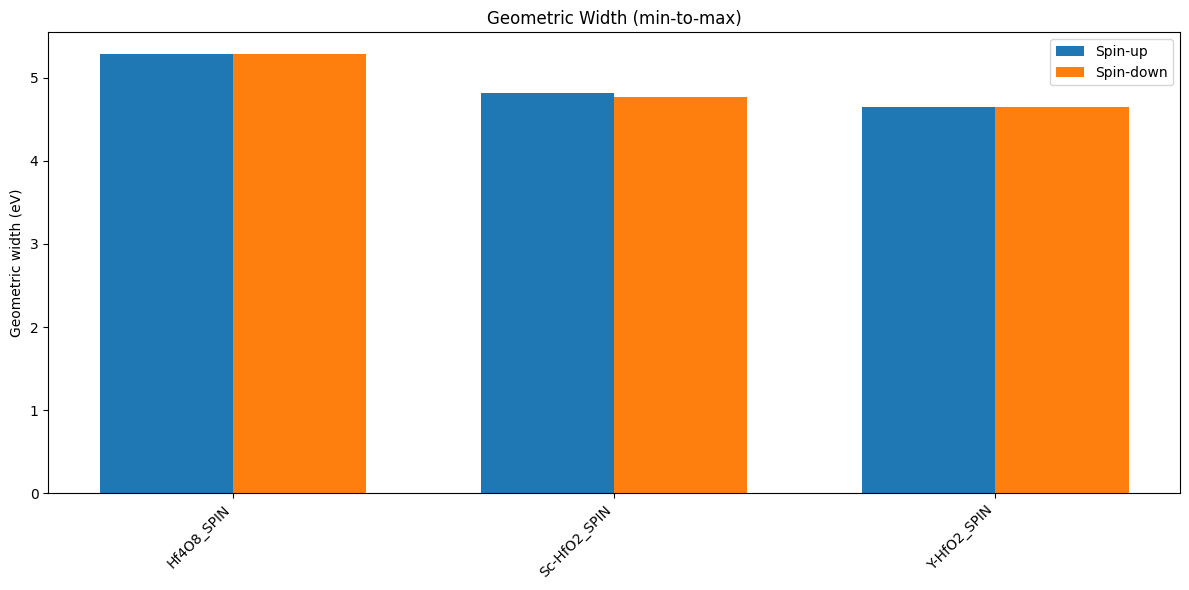

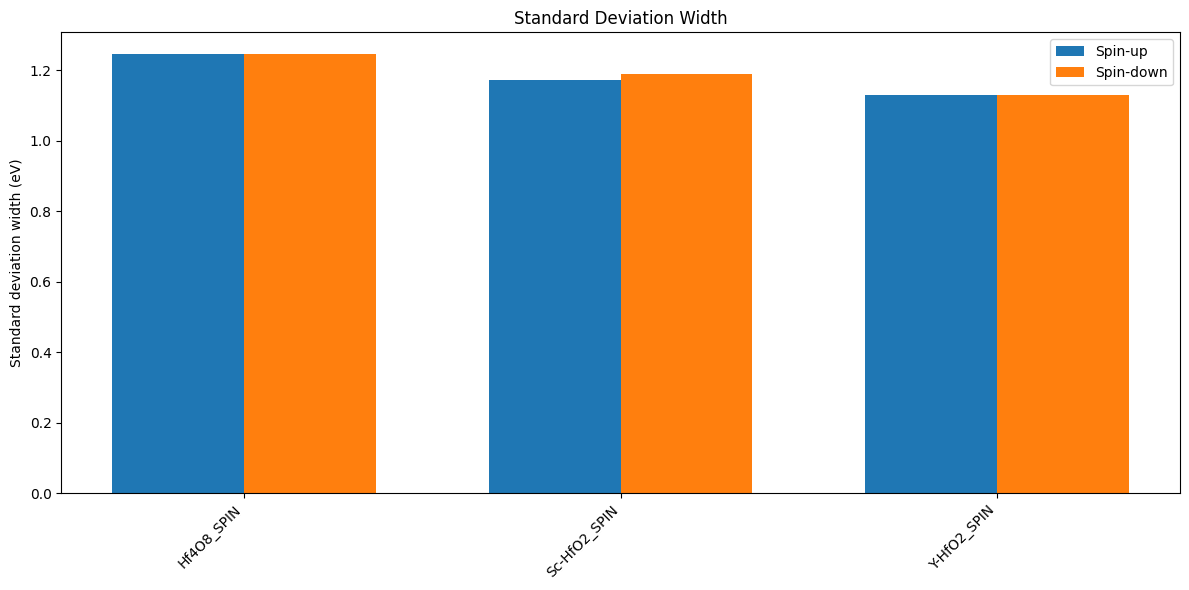

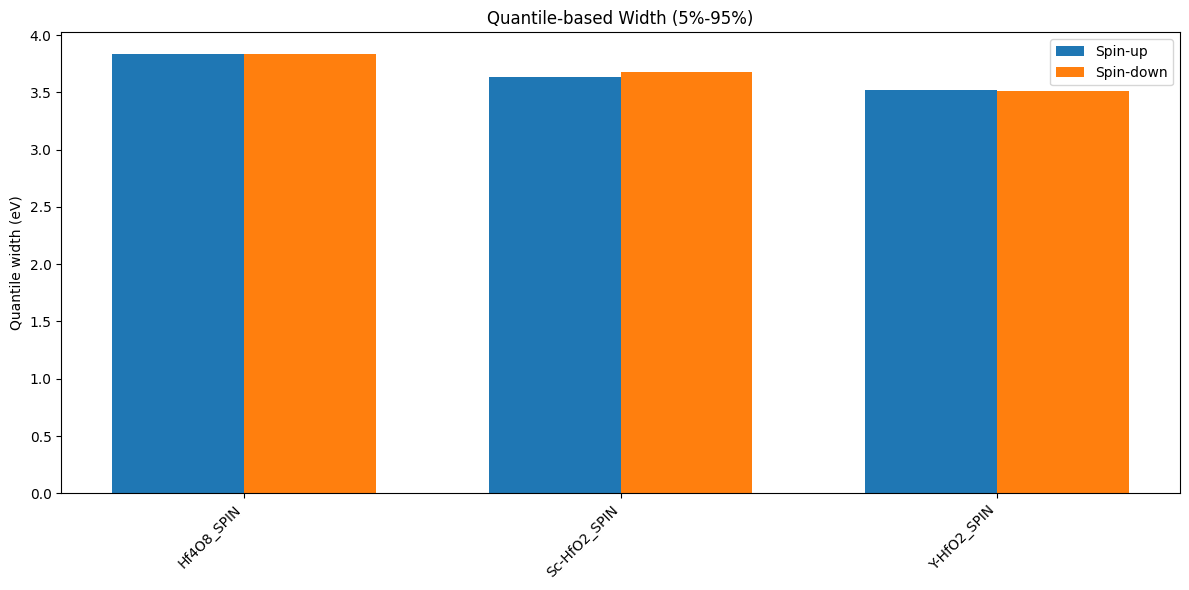

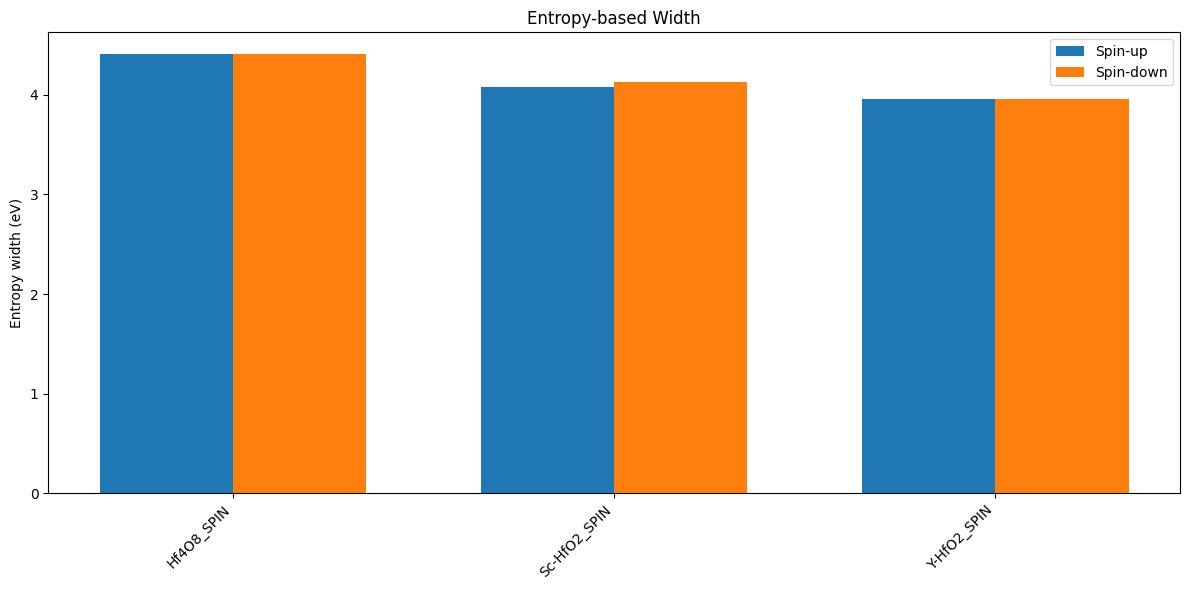

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def weighted_quantile(values, weights, quantile):
    """
    计算加权分位数
    """
    sorter = np.argsort(values)
    values_sorted = values[sorter]
    weights_sorted = weights[sorter]
    cum_weights = np.cumsum(weights_sorted)
    total = cum_weights[-1]
    return np.interp(quantile * total, cum_weights, values_sorted)

def calc_dband_properties(E, dos, threshold_fraction=0.01):
    """
    计算给定能量 E (数组) 和 DOS (数组) 的五个量：
      d_center：一阶矩（加权平均能量）
      geom_width：几何宽度（dos大于阈值的能量区间跨度）
      std_width：标准差宽度（二阶矩）
      quantile_width：分位数宽度 (E_95% - E_5%)
      entropy_width：基于信息熵的宽度 exp(S)
    """
    integral = np.trapz(dos, E)
    if integral == 0:
        return (np.nan, np.nan, np.nan, np.nan, np.nan)
    
    # d 带中心：ε_d = (∫ E * dos dE) / (∫ dos dE)
    d_center = np.trapz(E * dos, E) / integral
    
    # 标准差宽度： W_std = sqrt( (∫ (E-ε_d)^2 * dos dE) / (∫ dos dE) )
    diff2 = np.trapz(((E - d_center) ** 2) * dos, E)
    std_width = np.sqrt(diff2 / integral)
    
    # 几何宽度（min-to-max）：在 DOS 超过阈值（threshold_fraction*max(DOS)）的区域内计算
    max_dos = np.max(dos)
    threshold = threshold_fraction * max_dos
    mask = dos > threshold
    if np.any(mask):
        geom_width = E[mask].max() - E[mask].min()
    else:
        geom_width = np.nan
    
    # 分位数宽度：利用加权分位数（5%和95%）
    q05 = weighted_quantile(E, dos, 0.05)
    q95 = weighted_quantile(E, dos, 0.95)
    quantile_width = q95 - q05
    
    # 信息熵宽度：先归一化DOS为概率分布 p = dos/integral，再计算香农熵 S = -∫ p ln(p)dE，
    # 定义熵宽度为 exp(S)
    p = dos / integral
    # 避免对0取对数
    p = np.where(p > 0, p, 1e-12)
    S = -np.trapz(p * np.log(p), E)
    entropy_width = np.exp(S)
    
    return (d_center, geom_width, std_width, quantile_width, entropy_width)

# 读取 CSV 文件
data = pd.read_csv("combined_pdos_side_by_side.csv")

# 设置能量范围（单位 eV），确保覆盖完整的 d 带区间
E_min = -10.0
E_max = 0

# 用于存储结果，结果将以字典形式保存
results = {}

# 遍历所有模型，依据列名后缀 '_energy'
for col in data.columns:
    if col.endswith('_energy'):
        prefix = col[:-len('_energy')]
        energy_col = prefix + '_energy'
        d_up_col = prefix + '_d_up'
        d_down_col = prefix + '_d_down'
        
        if all(x in data.columns for x in [energy_col, d_up_col, d_down_col]):
            # 读取能量和 DOS 数据
            E = data[energy_col].values
            dos_up = data[d_up_col].values
            dos_down = data[d_down_col].values
            # 对自旋下 DOS 取绝对值，防止负值影响积分
            dos_down = np.abs(dos_down)
            
            # 筛选出在指定能量范围内的数据
            mask = (E >= E_min) & (E <= E_max)
            E_range = E[mask]
            dos_up_range = dos_up[mask]
            dos_down_range = dos_down[mask]
            
            if len(E_range) == 0:
                print(f"{prefix}: No data in specified energy range. Skipping.")
                continue
            
            # 分别计算自旋上和自旋下的d带性质
            d_center_up, geom_width_up, std_width_up, quantile_width_up, entropy_width_up = calc_dband_properties(E_range, dos_up_range)
            d_center_down, geom_width_down, std_width_down, quantile_width_down, entropy_width_down = calc_dband_properties(E_range, dos_down_range)
            
            results[prefix] = {
                'd_center_up': d_center_up,
                'geom_width_up': geom_width_up,
                'std_width_up': std_width_up,
                'quantile_width_up': quantile_width_up,
                'entropy_width_up': entropy_width_up,
                'd_center_down': d_center_down,
                'geom_width_down': geom_width_down,
                'std_width_down': std_width_down,
                'quantile_width_down': quantile_width_down,
                'entropy_width_down': entropy_width_down
            }

# 将结果保存为 DataFrame 并写入 CSV 文件
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df.index.name = 'model'
results_df.to_csv("d_band_properties_extended.csv")
print("Saved d_band_properties_extended.csv")

# 可视化部分：分别绘制 d_center、geom_width、std_width、quantile_width 和 entropy_width 对比图（自旋上 vs 自旋下）
models = list(results.keys())
x = np.arange(len(models))
width = 0.35

# 准备绘图函数
def plot_property(property_up, property_down, ylabel, title, filename):
    up_vals = [results[model][property_up] for model in models]
    down_vals = [results[model][property_down] for model in models]
    
    fig, ax = plt.subplots(figsize=(12,6))
    ax.bar(x - width/2, up_vals, width, label='Spin-up')
    ax.bar(x + width/2, down_vals, width, label='Spin-down')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# 绘制各指标图
plot_property('d_center_up', 'd_center_down', 'd-band center (eV)', 'd-band Center', 'd_band_center.png')
plot_property('geom_width_up', 'geom_width_down', 'Geometric width (eV)', 'Geometric Width (min-to-max)', 'geom_width.png')
plot_property('std_width_up', 'std_width_down', 'Standard deviation width (eV)', 'Standard Deviation Width', 'std_width.png')
plot_property('quantile_width_up', 'quantile_width_down', 'Quantile width (eV)', 'Quantile-based Width (5%-95%)', 'quantile_width.png')
plot_property('entropy_width_up', 'entropy_width_down', 'Entropy width (eV)', 'Entropy-based Width', 'entropy_width.png')


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def weighted_quantile(values, weights, quantile):
    """
    计算加权分位数
    """
    sorter = np.argsort(values)
    values_sorted = values[sorter]
    weights_sorted = weights[sorter]
    cum_weights = np.cumsum(weights_sorted)
    total = cum_weights[-1]
    return np.interp(quantile * total, cum_weights, values_sorted)

def calc_dband_properties(E, dos, threshold_fraction=0.01):
    """
    计算给定能量 E (数组) 和 DOS (数组) 的五个量：
      d_center：一阶矩（加权平均能量）
      geom_width：几何宽度（dos大于阈值的能量区间跨度）
      std_width：标准差宽度（二阶矩）
      quantile_width：分位数宽度 (E_95% - E_5%)
      entropy_width：基于信息熵的宽度 exp(S)
    """
    integral = np.trapz(dos, E)
    if integral == 0:
        return (np.nan, np.nan, np.nan, np.nan, np.nan)
    
    # d 带中心：ε_d = (∫ E * dos dE) / (∫ dos dE)
    d_center = np.trapz(E * dos, E) / integral
    
    # 标准差宽度： W_std = sqrt( (∫ (E-ε_d)^2 * dos dE) / (∫ dos dE) )
    diff2 = np.trapz(((E - d_center) ** 2) * dos, E)
    std_width = np.sqrt(diff2 / integral)
    
    # 几何宽度（min-to-max）：在 DOS 超过阈值（threshold_fraction*max(DOS)）的区域内计算
    max_dos = np.max(dos)
    threshold = threshold_fraction * max_dos
    mask = dos > threshold
    if np.any(mask):
        geom_width = E[mask].max() - E[mask].min()
    else:
        geom_width = np.nan
    
    # 分位数宽度：利用加权分位数（5%和95%）
    q05 = weighted_quantile(E, dos, 0.05)
    q95 = weighted_quantile(E, dos, 0.95)
    quantile_width = q95 - q05
    
    # 信息熵宽度：先归一化DOS为概率分布 p = dos/integral，再计算香农熵 S = -∫ p ln(p)dE，
    # 定义熵宽度为 exp(S)
    p = dos / integral
    p = np.where(p > 0, p, 1e-12)  # 避免对0取对数
    S = -np.trapz(p * np.log(p), E)
    entropy_width = np.exp(S)
    
    return (d_center, geom_width, std_width, quantile_width, entropy_width)

# 读取 CSV 文件
data = pd.read_csv("combined_pdos_side_by_side.csv")

# 设置能量范围（单位 eV），确保覆盖完整的 d 带区间
E_min = -10.0
E_max = 0

# 用于存储结果，结果将以字典形式保存
results = {}

# 遍历所有模型，依据列名后缀 '_energy'
for col in data.columns:
    if col.endswith('_energy'):
        prefix = col[:-len('_energy')]
        energy_col = prefix + '_energy'
        d_up_col = prefix + '_d_up'
        d_down_col = prefix + '_d_down'
        
        if all(x in data.columns for x in [energy_col, d_up_col, d_down_col]):
            # 读取能量和 DOS 数据
            E = data[energy_col].values
            dos_up = data[d_up_col].values
            dos_down = data[d_down_col].values
            # 对自旋下 DOS 取绝对值
            dos_down = np.abs(dos_down)
            
            # 筛选出在指定能量范围内的数据
            mask = (E >= E_min) & (E <= E_max)
            E_range = E[mask]
            dos_up_range = dos_up[mask]
            dos_down_range = dos_down[mask]
            
            if len(E_range) == 0:
                print(f"{prefix}: No data in specified energy range. Skipping.")
                continue
            
            # 分别计算自旋上和自旋下的d带性质
            d_center_up, geom_width_up, std_width_up, quantile_width_up, entropy_width_up = calc_dband_properties(E_range, dos_up_range)
            d_center_down, geom_width_down, std_width_down, quantile_width_down, entropy_width_down = calc_dband_properties(E_range, dos_down_range)
            
            results[prefix] = {
                'd_center_up': d_center_up,
                'd_center_down': d_center_down,
                'geom_width_up': geom_width_up,
                'geom_width_down': geom_width_down,
                'std_width_up': std_width_up,
                'std_width_down': std_width_down,
                'quantile_width_up': quantile_width_up,
                'quantile_width_down': quantile_width_down,
                'entropy_width_up': entropy_width_up,
                'entropy_width_down': entropy_width_down
            }

# 将结果保存为 DataFrame 并写入 CSV 文件
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df.index.name = 'model'
results_df.to_csv("d_band_properties_extended_Ef.csv")
print("Saved d_band_properties_extended.csv")

# 可视化部分：分别绘制各指标对比图（自旋上 vs 自旋下），图像只保存不显示
models = list(results.keys())
x = np.arange(len(models))
width = 0.35

def plot_property(property_up, property_down, ylabel, title, filename):
    up_vals = [results[model][property_up] for model in models]
    down_vals = [results[model][property_down] for model in models]
    
    fig, ax = plt.subplots(figsize=(12,6))
    ax.bar(x - width/2, up_vals, width, label='Spin-up')
    ax.bar(x + width/2, down_vals, width, label='Spin-down')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()

# 绘制各指标图，并保存到文件
plot_property('d_center_up', 'd_center_down', 'd-band center (eV)', 'd-band Center', 'd_band_center.png')
plot_property('geom_width_up', 'geom_width_down', 'Geometric width (eV)', 'Geometric Width (min-to-max)', 'geom_width.png')
plot_property('std_width_up', 'std_width_down', 'Standard deviation width (eV)', 'Standard Deviation Width', 'std_width.png')
plot_property('quantile_width_up', 'quantile_width_down', 'Quantile width (eV)', 'Quantile-based Width (5%-95%)', 'quantile_width.png')
plot_property('entropy_width_up', 'entropy_width_down', 'Entropy width (eV)', 'Entropy-based Width', 'entropy_width.png')

# 最后，将所有结果打印出来
print("Model d-band properties (extended):")
print(results_df)


Saved d_band_properties_extended.csv
Model d-band properties (extended):
              d_center_up  d_center_down  geom_width_up  geom_width_down  \
model                                                                      
Hf4O8_SPIN      -3.077922      -3.077917          5.282            5.282   
Sc-HfO2_SPIN    -2.713224      -2.634072          4.817            4.774   
Y-HfO2_SPIN     -2.575626      -2.576478          4.644            4.644   

              std_width_up  std_width_down  quantile_width_up  \
model                                                           
Hf4O8_SPIN        1.244741        1.244744           3.833047   
Sc-HfO2_SPIN      1.173152        1.188444           3.632366   
Y-HfO2_SPIN       1.128877        1.128631           3.517726   

              quantile_width_down  entropy_width_up  entropy_width_down  
model                                                                    
Hf4O8_SPIN               3.833061          4.407261            4.407267 